In [24]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt
import pickle

from mis_dro.dataset import sample_dgp
from mis_dro.bayes_conjugates import *
from mis_dro.likelihood import cholesky_param_to_covariance
from mis_dro.plot import *
from mis_dro.experiments import ExperimentName
from mis_dro.main import get_npl_uuid, POSTERIOR_GB_COLS

from matplotlib import rc
rc('font', **{'family': 'serif', 'serif': ['Computer Modern'], "size":20})
rc('text', usetex=False)

In [25]:
experiment_name = ExperimentName.mmd_portfolio_synthetic
mmd_experiment_dir = Path(f"/dcs/pg24/u5674159/mis-dro-code/mmd_portfolio_synthetic-repeat/experiment_dir")
npl_samples_dir = Path(f"/dcs/pg24/u5674159/mis-dro-code/mmd_portfolio_synthetic-repeat/npl_samples_dir")
assert mmd_experiment_dir.exists()
assert npl_samples_dir.exists()
with open(mmd_experiment_dir / "experiment.json", "r", encoding="utf-8") as json_file:
    experiment = json.load(json_file)
mmd_results_df = pd.read_csv(mmd_experiment_dir / "results.csv", index_col=["uuid", "replication"])

kl_experiment_dir = Path("/dcs/pg24/u5674159/mis-dro-code/kl_portfolio_synthetic-repeat-parrot")
assert kl_experiment_dir.exists()
kl_results_df = pd.read_csv(kl_experiment_dir / "results.csv", index_col=["uuid", "replication"])

all_results_df = pd.concat([mmd_results_df, kl_results_df])
all_results_df

solution  \
uuid                                 replication                                                      
51f4164b-9e06-4672-a06c-bba9643c1588 0            [np.float64(1.2901534015087249e-09), np.float6...   
                                     1            [np.float64(4.760429057462859e-08), np.float64...   
                                     2            [np.float64(4.835255872241173e-09), np.float64...   
                                     3            [np.float64(1.0391558208951399e-09), np.float6...   
                                     4            [np.float64(3.1704807770819088e-09), np.float6...   
...                                                                                             ...   
ff3dce59-3640-4893-aff4-1f401eb509fe 95           [np.float64(0.8750041850365037), np.float64(8....   
                                     96           [np.float64(0.8653733775958093), np.float64(2....   
                                     97           [np.float64(0.8208310056667713), np.float64(4....   
                                     98           [np.float64(0.9402775435185504), np.float64(7....   
                                     99           [np.float64(0.8825866655787744), np.float64(6....   

                                                  dgp_time  likelihood_time  \
uuid                                 replication                              
51f4164b-9e06-4672-a06c-bba9643c1588 0            0.034930         0.021666   
                                     1            0.074155         0.023805   
                                     2            0.032084         0.022894   
                                     3            0.005340         0.019601   
                                     4            0.003487         0.023741   
...                                                    ...              ...   
ff3dce59-3640-4893-aff4-1f401eb509fe 95           0.002268         0.000001   
                                     96           0.002161         0.000001   
                                     97           0.002274         0.000002   
                                     98           0.002191         0.000002   
                                     99           0.002102         0.000001   

                                                  posterior_time  solve_time  \
uuid                                 replication                               
51f4164b-9e06-4672-a06c-bba9643c1588 0                  0.003713  311.719385   
                                     1                  0.073461  318.858834   
                                     2                  0.069818  300.583583   
                                     3                  0.008524  310.667895   
                                     4                  0.005439  302.795100   
...                                                          ...         ...   
ff3dce59-3640-4893-aff4-1f401eb509fe 95                 0.001820    0.193037   
                                     96                 0.001742    0.191585   
                                     97                 0.001805    0.191102   
                                     98                 0.001740    0.189593   
                                     99                 0.001576    0.099034   

                                                  setup_time  \
uuid                                 replication               
51f4164b-9e06-4672-a06c-bba9643c1588 0                   NaN   
                                     1                   NaN   
                                     2                   NaN   
                                     3                   NaN   
                                     4                   NaN   
...                                                      ...   
ff3dce59-3640-4893-aff4-1f401eb509fe 95                  NaN   
                                     96                  NaN   
                                     97   

In [26]:
# NOTE filter by DGP
filter_dgp = "portfolio_contaminated_multivariate_normal"
dataset = "portfolio_synthetic"
# assert filter_dgp in all_results_df["dgp"] and dataset in all_results_df["dataset"]
results_df = preprocess_results_df(all_results_df, filter_dgp, dataset=dataset)
agg_df = get_agg_df(results_df, ["algorithm", "contamination", "epsilon", "inference"])
agg_df

/dcs/pg24/u5674159/mis-dro-code/mis_dro/plot.py:216: FutureWarning: The provided callable <function mean at 0x7fd8382d8fe0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  agg_df = gb.agg(
/dcs/pg24/u5674159/mis-dro-code/mis_dro/plot.py:216: FutureWarning: The provided callable <function std at 0x7fd8382d9120> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  agg_df = gb.agg(


out_of_sample_mean  \
algorithm   contamination epsilon inference                       
dro_bas_mmd 0.0           0.0001  npl_mmd              3.382704   
                          0.0010  npl_mmd              3.382704   
                          0.0050  npl_mmd              3.388106   
                          0.0100  npl_mmd              3.388919   
                          0.0500  npl_mmd              3.299558   
...                                                         ...   
kl_pp       0.2           1.0000  bayes                2.610138   
                          1.5000  bayes                2.599484   
                          2.0000  bayes                2.592645   
                          2.5000  bayes                2.587547   
                          3.0000  bayes                2.583237   

                                             out_of_sample_var  \
algorithm   contamination epsilon inference                      
dro_bas_mmd 0.0           0.0001  npl_mmd            28.012938   
                          0.0010  npl_mmd            28.012938   
                          0.0050  npl_mmd            27.948976   
                          0.0100  npl_mmd            27.692013   
                          0.0500  npl_mmd            22.878418   
...                                                        ...   
kl_pp       0.2           1.0000  bayes               4.372305   
                          1.5000  bayes               4.360895   
                          2.0000  bayes               4.364909   
                          2.5000  bayes               4.377054   
                          3.0000  bayes               4.395343   

                                             sum_of_in_group_var  \
algorithm   contamination epsilon inference                        
dro_bas_mmd 0.0           0.0001  npl_mmd              27.638493   
                          0.0010  npl_mmd              27.638493   
                          0.0050  npl_mmd              27.586832   
                          0.0100  npl_mmd              27.346259   
                          0.0500  npl_mmd              22.600176   
...                                                          ...   
kl_pp       0.2           1.0000  bayes                 4.324863   
                          1.5000  bayes                 4.313089   
                          2.0000  bayes                 4.316121   
                          2.5000  bayes                 4.326943   
                          3.0000  bayes                 4.343609   

                                             var_of_in_group_mean  \
algorithm   contamination epsilon inference                         
dro_bas_mmd 0.0           0.0001  npl_mmd                0.374445   
                          0.0010  npl_mmd                0.374445   
                          0.0050  npl_mmd                0.362144   
                          0.0100  npl_mmd                0.345754   
                          0.0500  npl_mmd                0.278242   
...                                                           ...   
kl_pp       0.2           1.0000  bayes                  0.047442   
                          1.5000  bayes                  0.047807   
                          2.0000  bayes                  0.048788   
                          2.5000  bayes                  0.050112   
                          3.0000  bayes                  0.051734   

                                             mean_solve_time  std_solve_time  \
algorithm   contamination epsilon inference                                    
dro_bas_mmd 0.0           0.0001  npl_mmd         298.059669        7.600270   
                          0.0010  npl_mmd         305.878860        6.137064   
                          0.0050  npl_mmd         297.723660       19.859724   
                          0.0100  npl_mmd         260.705214       15.304615   
                          0.0500  npl_mmd         2

In [ ]:
cols = ["mean_sample_time", "std_sample_time", "mean_solve_time", "std_solve_time"]

for algorithm in agg_df.index.get_level_values("algorithm").unique():
    print(f"\n=== {algorithm} ===")
    display(agg_df.xs(algorithm, level="algorithm")[cols])


=== dro_bas_mmd ===


mean_sample_time  std_sample_time  \
contamination epsilon inference                                      
0.0           0.0001  npl_mmd            0.055596         0.024846   
              0.0010  npl_mmd            0.054154         0.023932   
              0.0050  npl_mmd            0.048772         0.022813   
              0.0100  npl_mmd            0.056052         0.025102   
              0.0500  npl_mmd            0.055643         0.020917   
              0.1000  npl_mmd            0.052290         0.009370   
              0.1500  npl_mmd            0.051072         0.022983   
              0.2000  npl_mmd            0.051697         0.019034   
              0.3000  npl_mmd            0.047870         0.017534   
              0.5000  npl_mmd            0.053025         0.016616   
              1.0000  npl_mmd            0.052059         0.011414   
0.1           0.0001  npl_mmd            0.049781         0.012584   
              0.0010  npl_mmd            0.047943         0.028267   
              0.0050  npl_mmd            0.047216         0.014691   
              0.0100  npl_mmd            0.051054         0.012580   
              0.0500  npl_mmd            0.050731         0.011001   
              0.1000  npl_mmd            0.061128         0.085149   
              0.1500  npl_mmd            0.051661         0.011742   
              0.2000  npl_mmd            0.048392         0.013091   
              0.3000  npl_mmd            0.055329         0.016297   
              0.5000  npl_mmd            0.051719         0.011580   
              1.0000  npl_mmd            0.050595         0.017090   
0.2           0.0001  npl_mmd            0.054267         0.015236   
              0.0010  npl_mmd            0.044736         0.014557   
              0.0050  npl_mmd            0.049406         0.013389   
              0.0100  npl_mmd            0.055709         0.012685   
              0.0500  npl_mmd            0.058731         0.015622   
              0.1000  npl_mmd            0.040269         0.052233   
              0.1500  npl_mmd            0.035951         0.003496   
              0.2000  npl_mmd            0.034342         0.002477   
              0.3000  npl_mmd            0.038638         0.005434   
              0.5000  npl_mmd            0.038207         0.003287   
              1.0000  npl_mmd            0.035982         0.003126   

                                 mean_solve_time  std_solve_time  
contamination epsilon inference                                   
0.0           0.0001  npl_mmd         298.059669        7.600270  
              0.0010  npl_mmd         305.878860        6.137064  
              0.0050  npl_mmd         297.723660       19.859724  
              0.0100  npl_mmd         260.705214       15.304615  
              0.0500  npl_mmd         283.929127       13.977392  
              0.1000  npl_mmd         290.626291       14.145695  
              0.1500  npl_mmd         301.076855        8.346589  
              0.2000  npl_mmd         300.596053        6.973586  
              0.3000  npl_mmd         290.432850       15.950596  
              0.5000  npl_mmd         299.324044       10.393953  
              1.0000  npl_mmd         305.172094       10.881124  
0.1           0.0001  npl_mmd         307.460351       15.684425  
              0.0010  npl_mmd         302.511592        9.462796  
              0.0050  npl_mmd         302.081357        8.722216  
              0.0100  npl_mmd         305.991217       11.486388  
              0.0500  npl_mmd         292.104323        7.979230  
              0.1000  npl_mmd         294.321126        7.997295  
              0.1500  npl_mmd         287.774397        7.099722  
              0.2000  npl_mmd         303.173878       10.764352  
              0.3000  npl_mmd         306.388693        9.768371  
              0.5000  npl_mmd         298.290492        9.775013  
              1.0000  npl_mmd         299


=== empirical_mmd ===


mean_sample_time  std_sample_time  \
contamination epsilon inference                                      
0.0           0.0001  empirical          0.000016     1.504337e-06   
              0.0010  empirical          0.000016     1.233988e-06   
              0.0050  empirical          0.000016     1.184879e-06   
              0.0100  empirical          0.000016     1.748737e-06   
              0.0500  empirical          0.000016     1.417460e-06   
              0.1000  empirical          0.000016     1.545636e-06   
              0.1500  empirical          0.000016     2.997710e-06   
              0.2000  empirical          0.000016     1.719614e-06   
              0.3000  empirical          0.000016     1.493251e-06   
              0.5000  empirical          0.000016     1.934900e-06   
              1.0000  empirical          0.000015     1.292715e-06   
0.1           0.0001  empirical          0.000015     1.481332e-06   
              0.0010  empirical          0.000015     9.877533e-07   
              0.0050  empirical          0.000015     1.045626e-06   
              0.0100  empirical          0.000015     1.597062e-06   
              0.0500  empirical          0.000015     1.021931e-06   
              0.1000  empirical          0.000015     2.100385e-06   
              0.1500  empirical          0.000015     1.322837e-06   
              0.2000  empirical          0.000016     1.805827e-06   
              0.3000  empirical          0.000015     1.150274e-06   
              0.5000  empirical          0.000015     1.204537e-06   
              1.0000  empirical          0.000016     1.339229e-06   
0.2           0.0001  empirical          0.000015     1.304654e-06   
              0.0010  empirical          0.000016     1.424001e-06   
              0.0050  empirical          0.000015     1.644581e-06   
              0.0100  empirical          0.000015     8.645662e-07   
              0.0500  empirical          0.000015     1.152029e-06   
              0.1000  empirical          0.000015     1.602114e-06   
              0.1500  empirical          0.000015     1.554921e-06   
              0.2000  empirical          0.000015     1.291620e-06   
              0.3000  empirical          0.000016     2.043072e-06   
              0.5000  empirical          0.000016     1.364003e-06   
              1.0000  empirical          0.000016     1.251262e-06   

                                 mean_solve_time  std_solve_time  
contamination epsilon inference                                   
0.0           0.0001  empirical         2.957864        0.470625  
              0.0010  empirical         3.050874        0.225080  
              0.0050  empirical         3.177382        0.256103  
              0.0100  empirical         2.924495        0.378875  
              0.0500  empirical         2.878057        0.063686  
              0.1000  empirical         2.920490        0.087993  
              0.1500  empirical         2.900567        0.377063  
              0.2000  empirical         2.892201        0.069589  
              0.3000  empirical         2.888320        0.069431  
              0.5000  empirical         2.927215        0.379221  
              1.0000  empirical         2.915814        0.073006  
0.1           0.0001  empirical         2.896559        0.062050  
              0.0010  empirical         2.909657        0.167133  
              0.0050  empirical         2.894335        0.055882  
              0.0100  empirical         2.886836        0.052857  
              0.0500  empirical         2.899421        0.148862  
              0.1000  empirical         2.896188        0.056468  
              0.1500  empirical         2.896928        0.079423  
              0.2000  empirical         2.903895        0.182510  
              0.3000  empirical         2.886621        0.055084  
              0.5000  empirical         2.923201        0.061153  
              1.0000  empirical         3


=== kl_bdro ===


mean_sample_time  std_sample_time  \
contamination epsilon inference                                      
0.0           0.001   bayes              0.001949         0.000165   
              0.002   bayes              0.001889         0.000182   
              0.005   bayes              0.002073         0.000663   
              0.010   bayes              0.001947         0.000129   
              0.020   bayes              0.001943         0.000181   
...                                           ...              ...   
0.2           1.000   bayes              0.001653         0.000120   
              1.500   bayes              0.001672         0.000123   
              2.000   bayes              0.001686         0.000100   
              2.500   bayes              0.001855         0.000630   
              3.000   bayes              0.001742         0.000136   

                                 mean_solve_time  std_solve_time  
contamination epsilon inference                                   
0.0           0.001   bayes             0.203226        0.013256  
              0.002   bayes             0.204249        0.007282  
              0.005   bayes             0.209813        0.008834  
              0.010   bayes             0.210498        0.010202  
              0.020   bayes             0.208226        0.010973  
...                                          ...             ...  
0.2           1.000   bayes             0.181612        0.011986  
              1.500   bayes             0.181776        0.012083  
              2.000   bayes             0.182745        0.011261  
              2.500   bayes             0.194329        0.010619  
              3.000   bayes             0.192696        0.010336  

[84 rows x 4 columns]


=== kl_dro_bas ===


mean_sample_time  std_sample_time  \
contamination epsilon inference                                      
0.0           0.07    bayes              0.000278         0.000024   
              0.08    bayes              0.000320         0.000254   
              0.09    bayes              0.000286         0.000041   
              0.10    bayes              0.000322         0.000403   
              0.15    bayes              0.000307         0.000257   
              0.20    bayes              0.000283         0.000030   
              0.25    bayes              0.000292         0.000078   
              0.30    bayes              0.000281         0.000019   
              0.40    bayes              0.000288         0.000050   
              0.50    bayes              0.000287         0.000061   
              0.60    bayes              0.000282         0.000021   
              0.70    bayes              0.000332         0.000319   
              0.80    bayes              0.000311         0.000268   
              0.90    bayes              0.000281         0.000025   
              1.00    bayes              0.000280         0.000012   
              1.50    bayes              0.000310         0.000265   
              2.00    bayes              0.000281         0.000024   
              2.50    bayes              0.000282         0.000022   
              3.00    bayes              0.000280         0.000018   
0.1           0.07    bayes              0.000309         0.000262   
              0.08    bayes              0.000286         0.000052   
              0.09    bayes              0.000296         0.000068   
              0.10    bayes              0.000334         0.000316   
              0.15    bayes              0.000292         0.000050   
              0.20    bayes              0.000282         0.000024   
              0.25    bayes              0.000285         0.000028   
              0.30    bayes              0.000308         0.000242   
              0.40    bayes              0.000283         0.000029   
              0.50    bayes              0.000334         0.000424   
              0.60    bayes              0.000292         0.000051   
              0.70    bayes              0.000287         0.000065   
              0.80    bayes              0.000286         0.000027   
              0.90    bayes              0.000354         0.000514   
              1.00    bayes              0.000282         0.000034   
              1.50    bayes              0.000285         0.000046   
              2.00    bayes              0.000311         0.000233   
              2.50    bayes              0.000279         0.000016   
              3.00    bayes              0.000278         0.000020   
0.2           0.07    bayes              0.000383         0.000300   
              0.08    bayes              0.000347         0.000034   
              0.09    bayes              0.000360         0.000089   
              0.10    bayes              0.000366         0.000060   
              0.15    bayes              0.000427         0.000408   
              0.20    bayes              0.000347         0.000321   
              0.25    bayes              0.000300         0.000034   
              0.30    bayes              0.000312         0.000089   
              0.40    bayes              0.000302         0.000060   
              0.50    bayes              0.000368         0.000496   
              0.60    bayes              0.000318         0.000039   
              0.70    bayes              0.000313         0.000030   
              0.80    bayes              0.000321         0.000050   
              0.90    bayes              0.000320         0.000043   
              1.00    bayes              0.000324         0.000054   
              1.50    bayes              0.000337         0.000261   
              2.00    bayes              0.000302         0.000034   
              2.50    bayes              0.


=== kl_pp ===


mean_sample_time  std_sample_time  \
contamination epsilon inference                                      
0.0           0.001   bayes              0.000867         0.000102   
              0.002   bayes              0.000868         0.000102   
              0.005   bayes              0.000903         0.000129   
              0.010   bayes              0.000882         0.000116   
              0.020   bayes              0.000867         0.000101   
...                                           ...              ...   
0.2           1.000   bayes              0.000923         0.000141   
              1.500   bayes              0.000896         0.000112   
              2.000   bayes              0.000895         0.000105   
              2.500   bayes              0.000921         0.000119   
              3.000   bayes              0.000899         0.000108   

                                 mean_solve_time  std_solve_time  
contamination epsilon inference                                   
0.0           0.001   bayes             0.295612        0.018091  
              0.002   bayes             0.283416        0.013981  
              0.005   bayes             0.277864        0.013984  
              0.010   bayes             0.270814        0.014985  
              0.020   bayes             0.262410        0.013185  
...                                          ...             ...  
0.2           1.000   bayes             0.245142        0.010678  
              1.500   bayes             0.245333        0.012535  
              2.000   bayes             0.251005        0.011298  
              2.500   bayes             0.255347        0.011666  
              3.000   bayes             0.258125        0.010211  

[84 rows x 4 columns]

findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: 

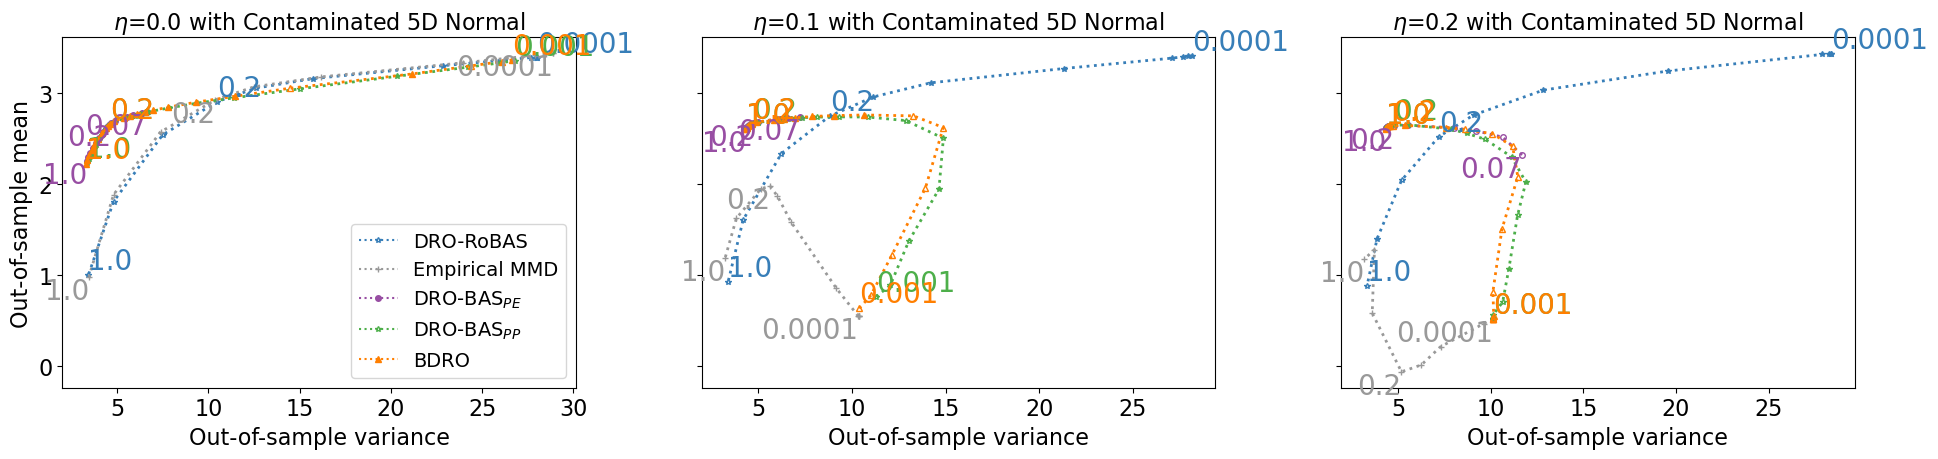

In [27]:
contamination_list = agg_df.index.get_level_values("contamination").unique().tolist()
nrows = 1
ncols = len(contamination_list)
trim_epsilon = 1.0
total_samples = 100
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(20,5), sharey=True)
fig.subplots_adjust(wspace=0.05)
pd.options.mode.chained_assignment = None  # default='warn'
trim_epsilon = 1.0
for j, contamination in enumerate(contamination_list):
    axis_df = agg_df.loc[:, contamination, :, :] #
    axis_df.loc[:, "is_pareto_front"] = is_maximise_pareto_front(axis_df["out_of_sample_var"].values, axis_df["out_of_sample_mean"].values)
    # for (algorithm, inference) in set(zip(axis_df.index.get_level_values("algorithm"), axis_df.index.get_level_values("inference"))):
    for (algorithm, inference) in [('dro_bas_mmd', "npl_mmd"), ('empirical_mmd', "empirical"), ('kl_dro_bas', "bayes"), ('kl_pp', "bayes"), ('kl_bdro', "bayes")]:
        df = axis_df.loc[algorithm, :trim_epsilon, inference]
        alpha = 1.0
        is_labelled=True
        mean_variance_plot(axes[j], df, **algorithm_inference_style(algorithm, inference, label_inference=False), offset=0.0, is_labelled=is_labelled, alpha=alpha, special_epsilons=[0.2])
    if j == 0:
        axes[j].legend(fontsize=14)
        axes[j].set_ylabel("Out-of-sample mean", fontsize=16)
        
    axes[j].set_title("$\eta$" + f"={contamination} with {NiceNameDGP[filter_dgp]}", fontsize=16)
    axes[j].set_xlabel("Out-of-sample variance", fontsize=16)
    axes[j].tick_params(axis='both', which='major', labelsize=12)
for ax in axes:
    ax.tick_params(axis='both', which='major', labelsize=16)
fig.tight_layout()
# plt.show()
fig.savefig(f"/dcs/pg24/u5674159/mis-dro-code/mmd_portfolio_synthetic-repeat/{experiment_name}.pdf", bbox_inches="tight")

In [28]:
mean_variance_plot_data_dict_list = []
for ax in axes:
    mean_variance_plot_data_dict = {}
    current_label = None
    lines = ax.get_lines()
    for i in range(len(lines)):
        line = lines[i]
        label = line.get_label()
        if label != "_nolegend_":
            current_label = label
        elif i == len(lines) - 1 or lines[i + 1].get_label() != "_nolegend_":
            x, y = line.get_xdata(), line.get_ydata()
            mean_variance_plot_data_dict[current_label] = {"x": x, "y": y}
    mean_variance_plot_data_dict_list.append(mean_variance_plot_data_dict)

directory_with_old_plot_data_for_replication = "/dcs/pg24/u5674159/mis-dro-code/james_old_plot_data_for_replication"
with open(f"{directory_with_old_plot_data_for_replication}/mean_variance_bdro_dro-bas_dro-robas_empirical_mmd_synthetic_data.pkl", "rb") as f:
    old_mean_variance_plot_data_dict_list = pickle.load(f)

assert len(old_mean_variance_plot_data_dict_list) == len(mean_variance_plot_data_dict_list)
for i in range(len(old_mean_variance_plot_data_dict_list)):
    old_mean_variance_plot_data_dict = old_mean_variance_plot_data_dict_list[i]
    mean_variance_plot_data_dict = mean_variance_plot_data_dict_list[i]
    assert old_mean_variance_plot_data_dict.keys() == mean_variance_plot_data_dict.keys()
    for key in old_mean_variance_plot_data_dict:
        for coord in "x", "y":
            assert np.array_equal(old_mean_variance_plot_data_dict[key][coord], mean_variance_plot_data_dict[key][coord])

In [29]:
idx = 10
dgp = experiment[idx]["dgp"]
num_observations = experiment[idx]["num_observations"]
contamination = experiment[idx]["contamination"]
dim = experiment[idx]["dim"]
replication = 0
generator = np.random.default_rng(replication)
data = sample_dgp(
    dgp, num_observations, dim=dim, contamination=contamination, generator=generator
)
dgp_mean = np.array([0.0, 1.5, -1.0, -3.0, 3.5])
dgp_mean_outl = dgp_mean + np.array([0.0, 50.0, 50.0, 50.0, 0.0])
dgp_cov = np.diag(np.array([1.0, 1.0, 1.0, 2.0, 3.0]))
print(json.dumps(experiment[idx], indent=4))

{
    "algorithm": "dro_bas_mmd",
    "contamination": 0.0,
    "dataset": "portfolio_synthetic",
    "dgp": "portfolio_contaminated_multivariate_normal",
    "dim": 5,
    "epsilon": 1.0,
    "eta": 0.1,
    "inference": "npl_mmd",
    "kernel_name": "k_comp",
    "lengthscale": -1.0,
    "likelihood": "multivariate_normal",
    "normalise": false,
    "num_certify_points": 200,
    "num_likelihood_samples": 10,
    "num_observations": 100,
    "num_posterior_samples": 90,
    "num_replications": 100,
    "num_test_observations": 100,
    "posterior": "npl",
    "uuid": "803c475e-d3d1-4fe5-baef-5f6deed7a23c"
}


In [30]:
# train a bayesian model with normal likelihood and NIW posterior
bayes_posterior = "normal_inverse_wishart"
theta_prior = default_prior_params(bayes_posterior, dim=dim)
theta_posterior = get_posterior_params(bayes_posterior, data, theta_prior)
mu_post, _, iota_post, Psi_post = theta_posterior
expected_Sigma = Psi_post / (iota_post - Psi_post.shape[0] - 1)

In [31]:
# load one NPL posterior sample
posterior_df = pd.read_csv(npl_samples_dir / "npl_settings.csv").set_index(POSTERIOR_GB_COLS)
npl_params = {key: experiment[idx][key] for key in POSTERIOR_GB_COLS}
npl_uuid = get_npl_uuid(posterior_df, npl_params)
npl_uuid_dir = npl_samples_dir / npl_uuid
path_to_csv = npl_uuid_dir / f"npl_sample_{replication}.csv"
theta_sample = pd.read_csv(path_to_csv, index_col=False, header=None).values
i = 0
npl_mu = theta_sample[i,:dim]
vec_cov = theta_sample[i,dim:]
npl_cov = cholesky_param_to_covariance(dim, vec_cov)
npl_cov

array([[ 5.15879074,  0.91152401, -0.40385315, -0.81296891,  2.4871794 ],
       [ 0.91152401,  9.89486057, -1.09881022, -1.22090222, -0.70924312],
       [-0.40385315, -1.09881022, 10.18754563, -2.72882154,  0.89558537],
       [-0.81296891, -1.22090222, -2.72882154, 21.70104723,  0.42350731],
       [ 2.4871794 , -0.70924312,  0.89558537,  0.42350731, 20.72369821]])

Text(0.5, 1.0, 'Bayes posterior')

findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: 

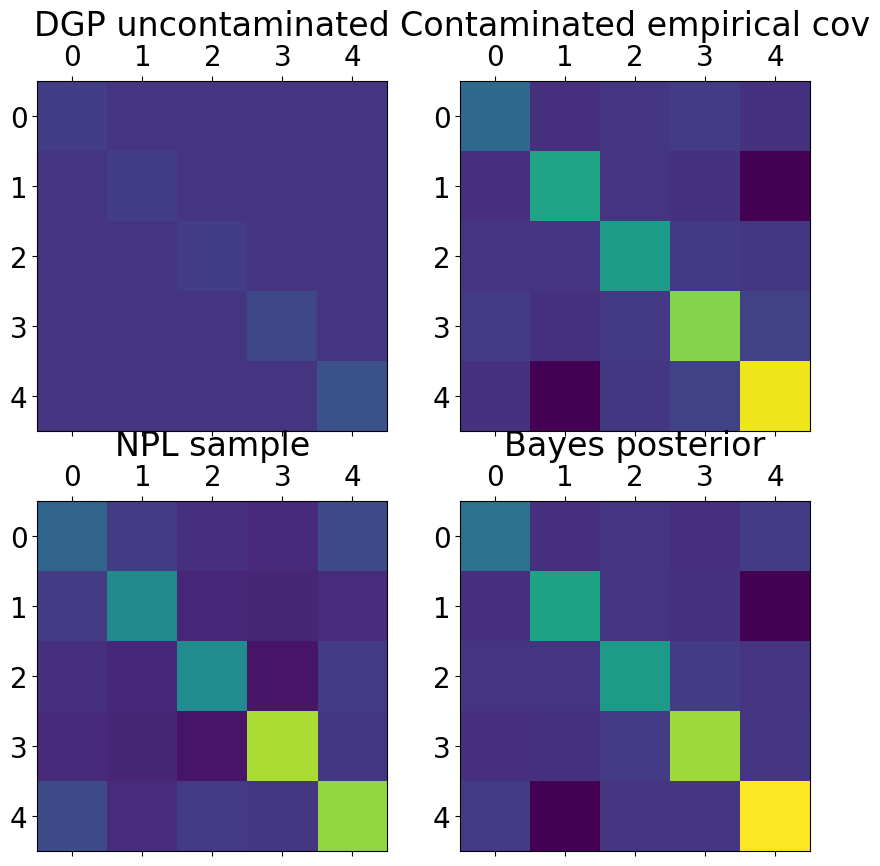

In [32]:
# plot the posterior against the DGP
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 10))
all_covs = np.concatenate([dgp_cov, expected_Sigma, np.cov(data.T), npl_cov])
vmax = np.max(all_covs)
vmin = np.min(all_covs)

axes[0][0].matshow(dgp_cov, vmin=vmin, vmax=vmax)
axes[0][0].set_title("DGP uncontaminated")

axes[0][1].matshow(np.cov(data.T), vmin=vmin, vmax=vmax)
axes[0][1].set_title("Contaminated empirical cov")

axes[1][0].matshow(npl_cov, vmin=vmin, vmax=vmax)
axes[1][0].set_title("NPL sample")

axes[1][1].matshow(expected_Sigma, vmin=vmin, vmax=vmax)
axes[1][1].set_title("Bayes posterior")

Text(0.5, 1.0, 'NPL sample')

findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: 

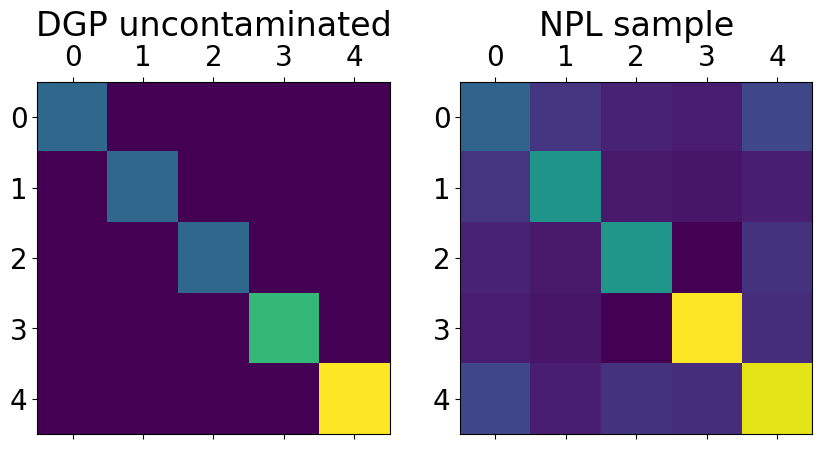

In [33]:
# plot the posterior against the DGP
fig, axes = plt.subplots(ncols=2, figsize=(10, 5))
all_covs = np.concatenate([dgp_cov, npl_cov])
vmax = np.max(all_covs)
vmin = np.min(all_covs)

axes[0].matshow(dgp_cov)
axes[0].set_title("DGP uncontaminated")

axes[1].matshow(npl_cov)
axes[1].set_title("NPL sample")
